# K-Means: Sistema de agrupación de casas
Queremos ser capaces de clasificar casas según su la región en la que se encuentren y del ingreso medio. Para ello, utilizaremos el famoso conjunto de datos California Housing. Se construyó utilizando los datos del censo de California de 1990. Contiene una fila por grupo de bloques censales. Un grupo de bloques es la unidad geográfica más pequeña para la que se publican datos del censo de USA.

## Paso 1: Cargar el conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre housing.csv. Puedes cargarlo en el código directamente desde el siguiente enlace:  
https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv  
O descargarlo y añadirlo a mano en tu repositorio. 

In [32]:
import pandas as pd

total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv")

total_data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3,41.0,7.0,1.0,322.0,2.6,37.9,-122.2,4.5
1,8.3,21.0,6.2,1.0,"2,401.0",2.1,37.9,-122.2,3.6
2,7.3,52.0,8.3,1.1,496.0,2.8,37.9,-122.2,3.5
3,5.6,52.0,5.8,1.1,558.0,2.5,37.9,-122.2,3.4
4,3.8,52.0,6.3,1.1,565.0,2.2,37.9,-122.2,3.4


### Eliminación de variables inútiles
En este caso solo nos interesan las columnas Latitude, Longitude y MedInc.

In [33]:
X = total_data[["MedInc", "Latitude", "Longitude"]]
X.head()

,MedInc,Latitude,Longitude
0,8.3,37.9,-122.2
1,8.3,37.9,-122.2
2,7.3,37.9,-122.2
3,5.6,37.9,-122.2
4,3.8,37.9,-122.2


### Dividir el conjunto de datos en entrenamiento y prueba

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.  

Aunque estos conjuntos no se utilicen para obtener estadísticas, podrás utilizarlos para entrenar el algoritmo no supervisado y luego para hacer predicciones sobre puntos nuevos para predecir el cluster al que se asocian.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size = 0.2, random_state = 42)

X_train.head()

,MedInc,Latitude,Longitude
14196,3.3,32.7,-117.0
8267,3.8,33.8,-118.2
17445,4.2,34.7,-120.5
14265,1.9,32.7,-117.1
2271,3.6,36.8,-119.8


## Paso 2: Construir un K-Means

Clasifica los datos en 6 clusters utilizando, para ello, el modelo K-Means.  

In [35]:
from sklearn.cluster import KMeans

model_unsup = KMeans(n_clusters = 6, n_init = "auto", random_state = 42)
model_unsup.fit(X_train)

KMeans(n_clusters=6, random_state=42)

### Insertar clusters en el conjunto de datos de entrenamiento
Almacena el cluster al que pertenece cada casa como una columna nueva del dataset.  
Podrías llamarla cluster.   
Para introducirla a tu conjunto de datos quizá tengas que categorizarla.

Observa qué formato y valores tiene y actúa en consecuencia. 

In [36]:
y_train = list(model_unsup.labels_)

    # model_unsup.labels_
    #    Esto accede a los labels asignados por el modelo K-Means para cada fila 
    #    del conjunto de entrenamiento (X_train).
        # - model_unsup es tu modelo KMeans ya entrenado.
        # - .labels_ es un atributo que devuelve un array con el número de cluster (int) asignado
        #   a cada muestra usada para entrenar el modelo.
        # - Ejemplo de salida: [3, 1, 1, 3, 5, ...]

    # list(...)
    #    Convierte ese array en una lista de Python pura (aunque normalmente se puede dejar 
    #    como numpy array sin problema).


X_train["cluster"] = y_train
    #    Crea una nueva columna llamada cluster en X_train, y le asigna a cada fila el número 
    #    de cluster que K-Means le asignó.

X_train.head()

,MedInc,Latitude,Longitude,cluster
14196,3.3,32.7,-117.0,3
8267,3.8,33.8,-118.2,1
17445,4.2,34.7,-120.5,1
14265,1.9,32.7,-117.1,3
2271,3.6,36.8,-119.8,5


In [37]:
# CUANDO DEBERIA CATEGORIZAR EL CLUSTER?
    # Los números de cluster (0, 1, ..., 5) están bien como enteros si luego los vas a 
    # usar como etiquetas en clasificación.
    # Solo tendrías que categorizarla si, por ejemplo:
        # - Quisieras convertirla a una variable de tipo string para visualizaciones.
        # - Necesitas usar one-hot encoding en un modelo que lo requiera (como redes neuronales).
        # - Vas a hacer algún análisis específico que lo necesite como category.
    # Por ahora, como estamos usando KMeans, está perfecto dejar los clusters como números enteros.

### Trazado de resultados
La Grafícamos en un diagrama de puntos y describimos lo que se ve.

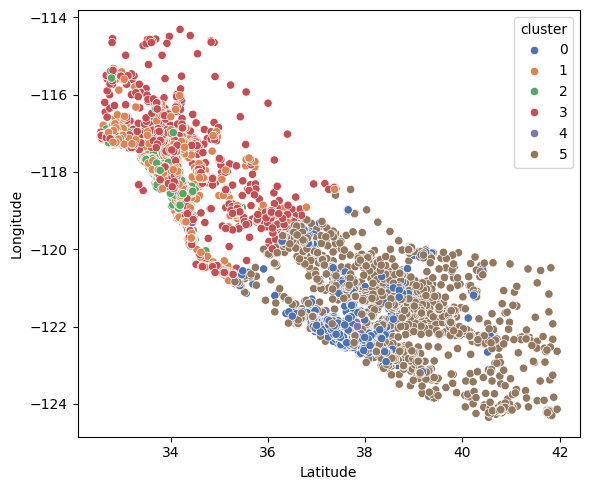

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico 1: Latitude vs Longitude
# --------------------------------------------------------------------

plt.figure(figsize=(6, 5))
sns.scatterplot(data = X_train, x = "Latitude", y = "Longitude", hue = "cluster", palette = "deep")
plt.tight_layout()
plt.show()

    # ¿Qué se está graficando?
        # - Se está graficando el mapa de California con los puntos de las casas.
        # - En el eje X se encuentra la Latitud, y en el eje Y la Longitud.
        # - Cada punto representa una casa, y el color del punto indica a qué cluster pertenece.

    # ¿Cómo se interpreta?
        # - Los clusters se forman por zonas geográficas, lo cual es lógico ya que Latitude y 
        #   Longitude son dos de las tres variables que usaste en el K-Means.
        # - Hay cierta separación clara de regiones, como una franja costera (posiblemente más costosa),
        #   zonas al sur, etc.

    # ¿Qué se puede mejorar?
        # - Podrías agregar un mapa de fondo para que sea más fácil de interpretar.
        # - Podrías agregar etiquetas o leyendas para indicar qué colores corresponden a qué clusters.
        # - Podrías ajustar el tamaño de los puntos para que sean más visibles o menos invasivos.


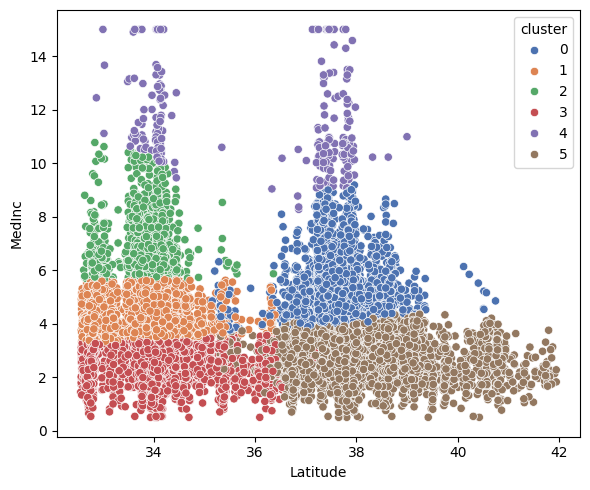

In [39]:
# Gráfico 2: Latitude vs MedInc
# --------------------------------------------------------------------

plt.figure(figsize=(6, 5))
sns.scatterplot(data = X_train, x = "Latitude", y = "MedInc", hue = "cluster", palette = "deep")
plt.tight_layout()
plt.show()


    # ¿Qué se está graficando?
        # - Se está graficando la Latitud contra el Ingreso Medio (MedInc).
        # - Cada punto representa una casa, y el color del punto indica a qué cluster pertenece.
        # - Se muestra la Relación entre ubicación norte-sur (Latitude) e ingreso medio.

    # ¿Cómo se interpreta?
        # - Algunos clusters están claramente asociados a ingresos más altos (por ejemplo, 
        #   el morado en la parte superior).
        # - Parece haber una división vertical en la que diferentes latitudes tienen diferentes 
        #   ingresos y están agrupadas en clusters distintos.
    
    # ¿Qué se puede mejorar?
        # - Podrías agregar etiquetas o leyendas para indicar qué colores corresponden a qué clusters.
        # - Podrías ajustar el tamaño de los puntos para que sean más visibles o menos invasivos.


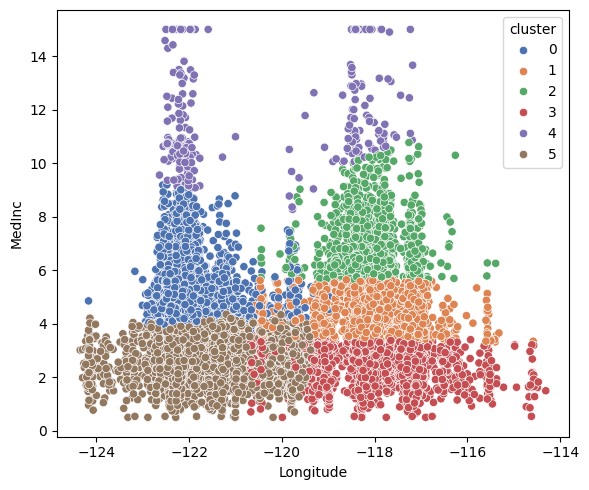

In [40]:
# Gráfico 3: Longitude vs MedInc
# --------------------------------------------------------------------

plt.figure(figsize=(6, 5))
sns.scatterplot(data = X_train, x = "Longitude", y = "MedInc", hue = "cluster", palette = "deep")
plt.tight_layout()
plt.show()

    # ¿Qué se está graficando?
        # - Se está graficando la Longitud contra el Ingreso Medio (MedInc).
        # - Cada punto representa una casa, y el color del punto indica a qué cluster pertenece.
        # - Relación entre ubicación este-oeste (Longitude) y MedInc.

    # ¿Cómo se interpreta?
        # - Puedes ver zonas costeras con diferentes niveles de ingreso.
        # - Hay un par de clusters que sobresalen con ingresos altos (tal vez áreas más urbanizadas 
        #   como Los Ángeles o San Francisco).
        # - Otras regiones (con longitudes más al este) tienden a tener ingresos más bajos.

    # ¿Qué se puede mejorar?
        # - Podrías agregar etiquetas o leyendas para indicar qué colores corresponden a qué clusters.
        # - Podrías ajustar el tamaño de los puntos para que sean más visibles o menos invasivos.

## Paso 3: Predecir con el conjunto de pruebas
Ahora utiliza el modelo entrenado con el conjunto test y añade los puntos al gráfico anterior para confirmar que la predicción es satisfactoria o no.

In [41]:
# En este paso estás utilizando el modelo de K-Means previamente entrenado para predecir los clusters de 
# los datos que el modelo no había visto aún, es decir, del conjunto de test (X_test). 

y_test = list(model_unsup.predict(X_test))

    # model_unsup.predict(X_test):
    # Esto aplica el modelo KMeans ya entrenado (model_unsup) sobre los nuevos datos (X_test).
        # - El modelo asigna a cada punto de test el número de cluster más cercano en función 
        #   de los centroides que ya aprendió.
        # - No está "reentrenando", solo clasificando nuevos puntos.

    # list(...)
        # - Convierte el array de resultados a una lista, aunque no es estrictamente necesario 
        #   (podrías usarlo directamente como NumPy array).

X_test["cluster"] = y_test

    # Añade la columna cluster al DataFrame X_test, indicando a qué grupo pertenece cada observación 
    # del conjunto de prueba.

X_test.head()

,MedInc,Latitude,Longitude,cluster
20046,1.7,36.1,-119.0,3
3024,2.5,35.1,-119.5,3
15663,3.5,37.8,-122.4,5
20484,5.7,34.3,-118.7,2
9814,3.7,36.6,-121.9,5


In [42]:
# Se ve consistente con lo que podrías esperar: casas con ingresos bajos y cierta latitud/longitud fueron 
# asignadas a clusters similares a los del train.

### Trazado de los resultados de las pruebas sobre la figura anterior

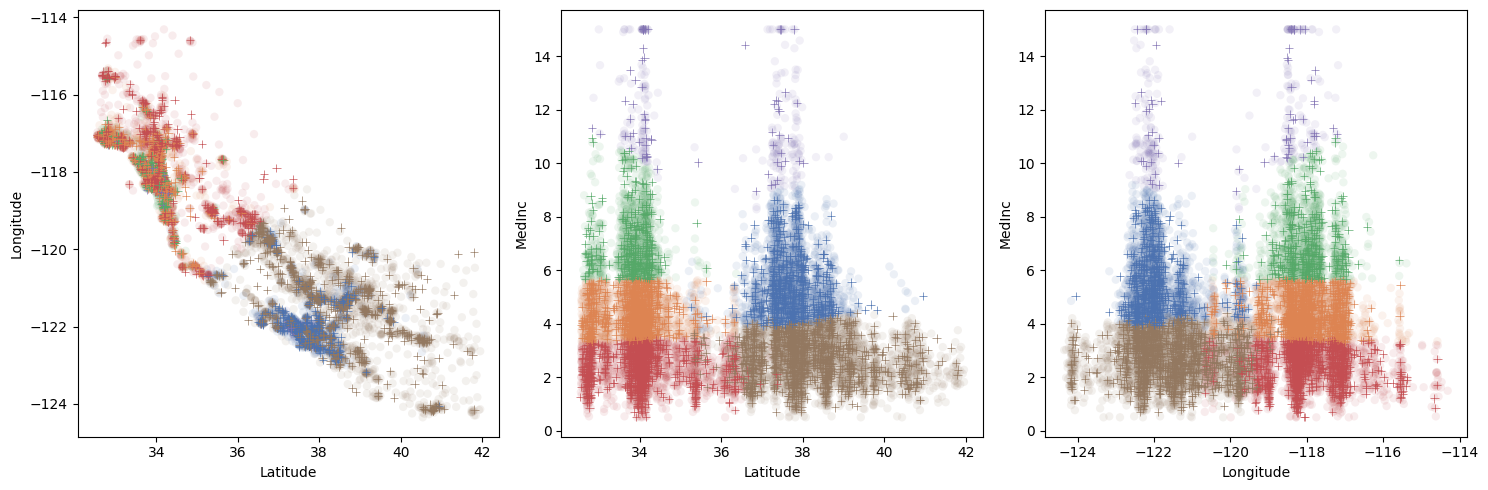

In [43]:
fig, axis = plt.subplots(1, 3, figsize = (15, 5))

sns.scatterplot(ax = axis[0], data = X_train, x = "Latitude", y = "Longitude", hue = "cluster", palette = "deep", alpha  = 0.1)
sns.scatterplot(ax = axis[1], data = X_train, x = "Latitude", y = "MedInc", hue = "cluster", palette = "deep", alpha  = 0.1)
sns.scatterplot(ax = axis[2], data = X_train, x = "Longitude", y = "MedInc", hue = "cluster", palette = "deep", alpha  = 0.1)

sns.scatterplot(ax = axis[0], data = X_test, x = "Latitude", y = "Longitude", hue = "cluster", palette = "deep", marker = "+")
sns.scatterplot(ax = axis[1], data = X_test, x = "Latitude", y = "MedInc", hue = "cluster", palette = "deep", marker = "+")
sns.scatterplot(ax = axis[2], data = X_test, x = "Longitude", y = "MedInc", hue = "cluster", palette = "deep", marker = "+")

plt.tight_layout()

for ax in axis:
    ax.legend([],[], frameon=False)

plt.show()

Como vemos, hay una gran fiabilidad a la hora de predecir a qué clúster pertenece cada punto de prueba.

## Paso 4: Entrenar un modelo de clasificación supervisado

Ahora que el K-Means nos ha devuelto una categorización (agrupación) de los puntos para los conjuntos de entrenamiento y prueba, estudia qué modelo podría ser más útil y entrénalo. Obtén las estadísticas y describe lo que ves.

Este flujo es muy común cuando contamos con datos no etiquetados: utilizar un modelo de aprendizaje no supervisado para etiquetarlos de forma automática y a continuación, un modelo de aprendizaje supervisado.

He elegido un Árbol de Decisión porque es una alternativa muy buena cuando queremos categorizar elementos según sus características intrínsecas, y no existe una relación lineal clara entre algunas variables. Además, no es necesario normalizar los valores.

In [44]:
from sklearn.tree import DecisionTreeClassifier

model_sup = DecisionTreeClassifier(random_state = 42)
model_sup.fit(X_train, y_train)


# ✔ X_train:
#   Contiene las características ["MedInc", "Latitude", "Longitude"] — las mismas que usó el 
#   modelo KMeans para agrupar.

# ✔ y_train:
#   Viene de model_unsup.labels_ — los clusters generados por KMeans, que ahora se usan 
#   como etiquetas.

# ✔ ¿Por qué tiene sentido este flujo?
#   Esto se llama "aprendizaje semi-supervisado" o "pseudo-etiquetado":
    # - Primero, agrupás los datos sin etiquetas usando un modelo no supervisado.
    # - Después, usás esos grupos como etiquetas falsas para entrenar un modelo supervisado.
    # - Así podés luego clasificar datos nuevos sin necesidad de repetir KMeans.

DecisionTreeClassifier(random_state=42)

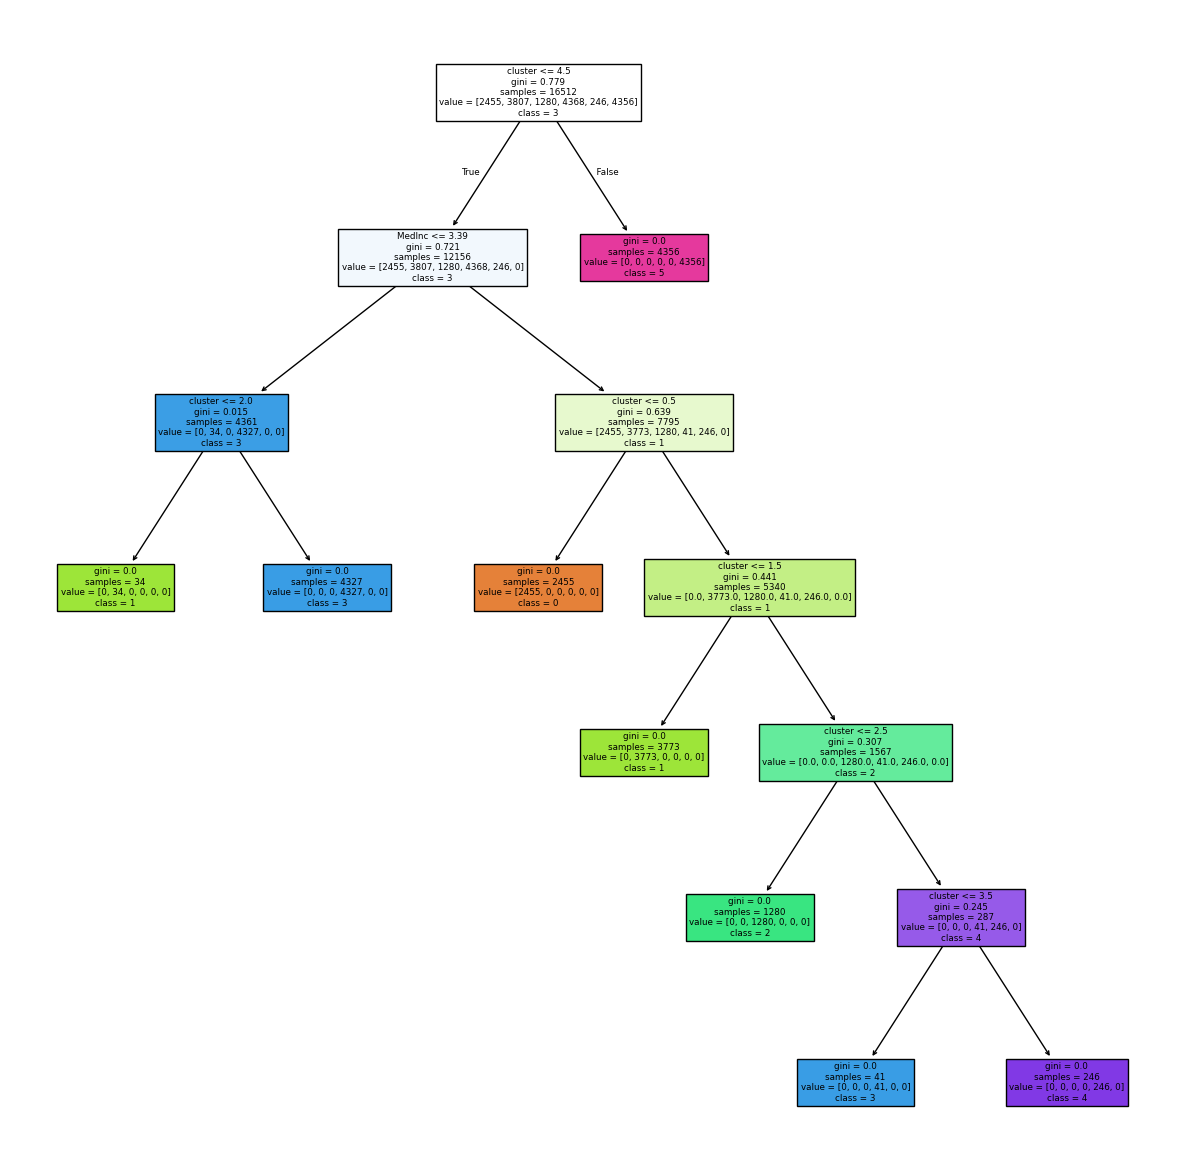

In [45]:
# Generemos el árbol de decisión entrenado para predecir los clusters de K-Means

from sklearn import tree

fig = plt.figure(figsize=(15,15))

tree.plot_tree(model_sup, feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3", "4", "5"], filled = True)

plt.show()

In [46]:
# 🧠 ¿Qué estamos viendo?
# Este árbol representa cómo el modelo DecisionTreeClassifier aprendió a asignar clusters (0 a 5) 
# usando tres variables:
    # - MedInc (Ingreso medio)
    # - Latitude
    # - Longitude

# Cada nodo del árbol:
    # - Tiene una condición de división (feature <= valor)
    # - Muestra la cantidad de muestras que llegaron ahí (samples)
    # - Muestra los valores por clase (cuántas observaciones por cluster)
    # - El color representa la clase mayoritaria (el cluster que predice ese nodo)

# 🔎 Observaciones clave del árbol:
    #  1. Primera división: cluster <= 4.5
        # - Separación fuerte entre los clusters más bajos (0–4) y el cluster 5 (último).
        # - El grupo 5 tiene patrones claramente distintos (quizá hogares con ingresos más 
        #   altos y ubicaciones particulares).

    #  2. MedInc tiene un papel central en la estructura del árbol:
        # - Varios nodos dependen directamente de cortes en el ingreso medio.
        #   Ej.: MedInc <= 3.19, MedInc <= 2.9, etc.

    #  3. Los nodos con gini = 0.0 indican pureza total:
        # Por ejemplo, si un nodo tiene value = [0, 0, 0, 100, 0, 0], 
        # significa que todas las observaciones en ese grupo pertenecen al cluster 3.

    #  4. Clusters 1 y 2 también son fáciles de separar:
        # Aparecen con splits claros en Latitude y MedInc, sin mucha ambigüedad.

# 🧩 Conclusión:
    # El Árbol de Decisión aprendió reglas bastante limpias y precisas para predecir los 
    # clusters de K-Means. Eso indica:
        # - Que los clusters de KMeans eran relativamente bien separados en el espacio de features.
        # - Que el árbol está funcionando como un modelo útil para categorizar nuevos puntos de forma rápida.

In [47]:
# Siguiente movimiento lógico tras entrenar el modelo supervisado: ahora lo estás probando 
# en el conjunto de test (X_test).

y_pred = model_sup.predict(X_test)
y_pred

# ✔ model_sup.predict(...)
#   Usás el árbol de decisión (model_sup) para predecir el cluster de cada casa en el conjunto X_test.
    # - Cada predicción es un número del 0 al 5 (los clusters que originalmente generó KMeans).
    # - El resultado es un numpy array de etiquetas predichas para las 4128 filas del test.

array([3, 3, 5, ..., 4, 5, 1], shape=(4128,), dtype=int32)

In [48]:
# evaluar el rendimiento

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

# accuracy_score
    # - Compara los valores verdaderos (y_test, que vienen de KMeans.predict) con las predicciones 
    #   del árbol (y_pred).
    # - Te devuelve la proporción de aciertos:
    #   accuracy = número de predicciones correctas / total de predicciones

1.0

In [49]:
# 📌 ¿Por qué 1.0 es lógico en este caso?
    # - Tu modelo supervisado (DecisionTreeClassifier) fue entrenado directamente con las 
    #   etiquetas de KMeans, que es el mismo modelo que produjo los y_test para los datos nuevos.

    # - En otras palabras, el árbol aprendió exactamente las reglas de KMeans,
    #   y las está replicando sin error sobre X_test.

    # - Si los clusters están bien separados y la información en MedInc, Latitude, Longitude 
    #   es suficiente, es perfectamente posible que el árbol logre reproducir el agrupamiento 
    #   con total precisión.

# El pipeline ya logró:
    # - Usar KMeans para agrupar sin etiquetas.
    # - Usar esas agrupaciones como etiquetas para un modelo supervisado.
    # - Validar que el modelo supervisado puede reproducir la agrupación con altísima (100%) fidelidad.

## Paso 5: Guardar los modelos
Almacena ambos modelos en la carpeta correspondiente.



In [50]:
from pickle import dump

dump(model_unsup, open("./models/k-means_default_42.sav", "wb"))
dump(model_sup, open("./models/decision_tree_classifier_default_42.sav", "wb"))